In [1]:
from importlib import reload
from read_idl import idlToPandas

In [2]:
dat = idlToPandas('./Data/20210224dat-5s.sav')
dat0 = dat

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import seaborn
from mpl_toolkits.basemap import Basemap
import datetime

flno = [2,3,4,6,7,8]
date = ["27 Jul", "29 Jul", "31 Jul", "2 Aug", "4 Aug", "6 Aug", "8 Aug", "10 Aug"]
colors = ["k","#045275","#0C7BDC","#7CCBA2","k","#FED976","#F0746E","#7C1D6F"]

In [4]:
dat.keys()

Index(['FLIGHT', 'MONTH', 'DAY', 'H2O', 'H2OM', 'HDO', 'H218OA', 'H218OB',
       'FLAG', 'CO2', 'CH4', 'N2O1', 'N2O2', 'UH2O', 'UH2OM', 'UHDO', 'UCO2',
       'UCH4', 'UN2O1', 'UN2O2', 'ZERO', 'PRES_CELL', 'TEMP_CELL', 'PRES_AMB',
       'TEMP_DET', 'TEMP_LAS', 'TEMP_FORE', 'TEMP_CENT', 'TEMP_AFT',
       'PRES_THROAT', 'V1POS', 'V2POS', 'PUMPRPM', 'PUMPCURRENT',
       'TEMP_PUMPHEAD', 'TEMP_PUMPMOTOR', 'TEMP_FAIRING', 'TIME', 'LAT', 'LON',
       'ALT_UCSE', 'PRES_UCSE', 'TEMP_UCSE', 'PT_UCSE', 'SATPPM_UCSE',
       'VTRUE_UCSE', 'DRIFT', 'HEAD', 'PITCH', 'ATTACK', 'SLIP', 'ROLL',
       'TRACK', 'SWIND_UCSE', 'DWIND_UCSE', 'ALT', 'PRES', 'TEMP', 'PT',
       'SATPPM', 'VTRUE', 'SWIND', 'DWIND', 'CDP_N', 'CDP_D', 'CIPGS_N',
       'CIPGS_D', 'CIP_N', 'CIP_D', 'PIP_N', 'PIP_D', 'CDP_PPM', 'CIPGS_PPM',
       'CIP_PPM', 'PIP_PPM', 'PARTICLES', 'MASBR', 'CLOUD', 'FLH2O', 'FIH2O',
       'IWC', 'NICE', 'HAGCO2', 'HAGN2O', 'HAGCH4', 'COLN2O', 'COLCO', 'AMICO',
       'FOZO3', 'NIXE_TEMP'

2 3.353333333333334
3 2.5775
4 3.309444444444445
6 2.833055555555556
7 1.9880555555555555
8 2.678055555555556

2 12.595000267028809 20.030000686645508
3 11.199000358581543 20.025999069213867
4 11.043999671936035 20.03700065612793
6 10.826000213623047 16.299999237060547
7 12.149999618530273 19.040000915527344
8 9.538999557495117 18.68199920654297

2 359.20001220703125 474.0
3 355.6000061035156 475.8999938964844
4 358.8999938964844 471.79998779296875
6 358.5 380.79998779296875
7 360.3999938964844 437.0
8 354.5 424.79998779296875



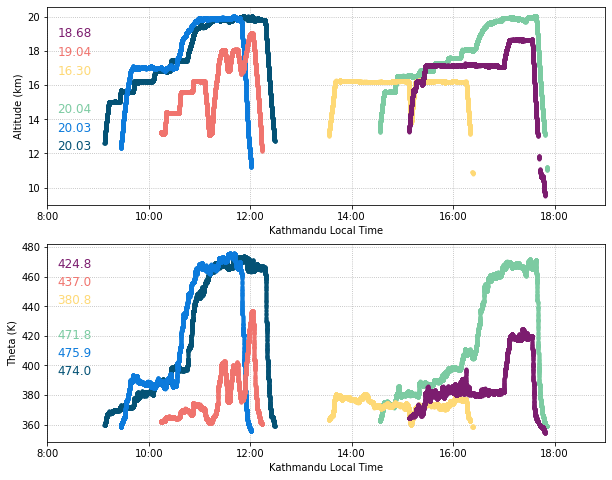

In [5]:
# print flight duration
for i in flno:
    dati = dat[(dat['FLIGHT'] == i) & (dat['H2O'] <= 100)]
    duration = np.max(dati['TIME'])/3600. - np.min(dati['TIME'])/3600.
    print(i, duration)
print()

fig,axes = plt.subplots(2,1,figsize=(10,8))

# plot altitude timeseries
ax = axes[0]
for i in flno:
    dati = dat[(dat['FLIGHT'] == i) & (dat['H2O'] <= 100)]
    ax.plot(dati['TIME']/3600.+5.75,dati['ALT'],'.',color=colors[i-1],label="F"+str(i)+", "+date[i-1])
    ax.text(8.2, 10+i*1.1, f"{np.max(dati['ALT']):.2f}", color=colors[i-1], fontsize=12)
    print(i, np.min(dati['ALT']), np.max(dati['ALT']))
print()

ax.set_xlabel("Kathmandu Local Time")
ax.set_ylabel("Altitude (km)")

ticks = [8,10,12,14,16,18]
ticks_name = [str(datetime.timedelta(hours=x)).rsplit(':',1)[0] for x in ticks]
ax.set_xlim([8, 19]) 
ax.set_xticks(ticks)
ax.set_xticklabels(ticks_name)

ax.grid(which='both',linestyle=':')

# plot theta timeseries
ax = axes[1]
for i in flno:
    dati = dat[(dat['FLIGHT'] == i) & (dat['H2O'] <= 100)]
    ax.plot(dati['TIME']/3600.+5.75,dati['PT'],'.',color=colors[i-1],label="F"+str(i)+", "+date[i-1])
    ax.text(8.2, 370+i*12, f"{np.max(dati['PT']):.1f}", color=colors[i-1], fontsize=12)
    print(i, np.min(dati['PT']), np.max(dati['PT']))
print()

ax.set_xlabel("Kathmandu Local Time")
ax.set_ylabel("Theta (K)")

ticks = [8,10,12,14,16,18]
ticks_name = [str(datetime.timedelta(hours=x)).rsplit(':',1)[0] for x in ticks]
ax.set_xlim([8, 19]) 
ax.set_xticks(ticks)
ax.set_xticklabels(ticks_name)

ax.grid(which='both',linestyle=':')

    
plt.show()